<a href="https://colab.research.google.com/github/Azi-Lizzy/ii-dlsca/blob/main/01_Ensemble_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Ensemble Learning
The code block below installs the necessary packages

In [3]:
!pip install numpy
!pip install h5py
!pip install trsfile
!pip install tensorflow==2.22.0rc0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 638.3/638.3 MB 881.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 16.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 require

Download and load in the dataset and the models

In [12]:
# Run this if zip:

!wget https://zenodo.org/records/23102432/files/Ensemble-Trained-Models.zip?download=1 -O Ensemble-Trained-Models.zip
!unzip Ensemble-Trained-Models.zip
!rm Ensemble-Trained-Models.zip

# Run this if data is .h5:
# !wget 'https://zenodo.org/records/23083982/files/Ascon-Protected.trs?download=1' -O Ascon-Protected.trs

# Run this for downloading the models:
# <TO BE FILLED HERE>

--2026-10-02 12:13:31--  https://zenodo.org/records/23102432/files/Ensemble-Trained-Models.zip?download=1-O
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 137.138.153.219, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8633270 (8.2M) [application/octet-stream]
Saving to: ‘Ensemble-Trained-Models.zip?download=1-O.1’

Ensemble-Trained-Mo 100%[===================>]   8.23M  1.17MB/s    in 7.7s    

2026-10-02 12:13:40 (1.06 MB/s) - ‘Ensemble-Trained-Models.zip?download=1-O.1’ saved [8633270/8633270]

--2026-10-02 12:13:40--  http://ensemble-trained-models.zip/
Resolving ensemble-trained-models.zip (ensemble-trained-models.zip)... failed: Name or service not known.
wget: unable to resolve host address ‘ensemble-trained-models.zip’
FINISHED --2026-10-02 12:13:40--
Total wall clock time: 8.3s
Downloaded: 1 files, 8.2M in 7.7s (1.06 MB/s)
unzip:  cannot find or open Ensemble-Trained-Mode

## Load in the dataset

In [2]:
import numpy as np
import trsfile

# Dataset settings: edit the path for your computer.
dataset_file = '/content/Ascon-Protected.trs'
n_profiling = 50000
n_attack = 5000
number_of_samples = 1408
target_byte = 4                 # 0..7, in the first key word
leakage_model = 'SB-8'          # 'SB-8' (256 classes) or 'HW' (9 classes). For Ascon SB-8 is equivalent to ID

assert 0 <= target_byte < 8
assert leakage_model in ('SB-8', 'HW')

# Read the profiling and attack blocks.
n_total = n_profiling + n_attack
samples = np.zeros((n_total, number_of_samples), dtype=np.float64)
nonces = np.zeros((n_total, 16), dtype=np.uint8)
keys = np.zeros((n_total, 16), dtype=np.uint8)

with trsfile.open(dataset_file, 'r') as traces:
    for i in range(n_total):
        trace = traces[i]
        samples[i] = trace.samples
        keys[i] = np.frombuffer(bytes(trace.parameters['key'].value), dtype=np.uint8)
        nonces[i, :8] = np.frombuffer(bytes(trace.parameters['nonce0'].value), dtype=np.uint8)
        nonces[i, 8:] = np.frombuffer(bytes(trace.parameters['nonce1'].value), dtype=np.uint8)

# We break the keys and nonces into two 8-byte halves, to match the original Ascon implementation.
key0 = keys[:, 0:8]
key1 = keys[:, 8:16]
nonces0 = nonces[:, 0:8]
nonces1 = nonces[:, 8:16]

X_profiling = samples[:n_profiling]
X_attack = samples[n_profiling:]

# Profiling data is needed anymore as we already have the trained models.
attack_data = np.zeros((n_attack, 4), dtype=np.uint8)
attack_data[:, 0] = key0[n_profiling:, target_byte]
attack_data[:, 1] = key1[n_profiling:, target_byte]
attack_data[:, 2] = nonces0[n_profiling:, target_byte]
attack_data[:, 3] = nonces1[n_profiling:, target_byte]

good_key = int(attack_data[0, 0])
assert np.all(attack_data[:, 0] == good_key), 'The attacked key byte must be fixed.'

# Apply the original z-score normalization, using profiling statistics only.
# The profiling data is just used to reproduce the z-score normalization parameters.
z_score_mean = np.mean(X_profiling, axis=0)
z_score_std = np.std(X_profiling, axis=0)
z_score_std[z_score_std == 0] = 1  # Avoid division by zero for constant samples.
X_attack = ((X_attack - z_score_mean) / z_score_std).astype('float32')

# Profiling samples are no longer needed: there is no training.
del samples, X_profiling, nonces, keys, key0, key1, nonces0, nonces1
print('Attack traces:', X_attack.shape)
print('Correct key byte:', good_key)

Attack traces: (5000, 1408)
Correct key byte: 45


## Load the best model and calculate the best GE we can get with the best model

With the time and resources we had we coud generate 60 random models. some of them where not converging to any small GE. but among them there was one best what that could reduce the GE to smal values. here you are going to reload this model again and use it for your attack. you need to calculate the GE according to the formiula that was shared with you during the presentation. This is the best GE we can get if we only use the best model that we found during our hyperparamether tuning (here random search)

In [3]:
# Loading the models and getting the probabilities
path_models = "/content/Ensemble-Trained-Models/"

from pathlib import Path
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K
import gc

model_folder = Path('/content/Ensemble-Trained-Models/best-found-model.keras')
model_files = 'best-found-model.keras'
batch_size = 128

# assert model_files and len(set(model_files)) == len(model_files), 'Use unique model filenames.'
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass  # The GPU may already be initialized if this cell is rerun.

best_model_probabilities = {}
for filename in model_files:
    print('Loading', filename)
    model = load_model(model_folder, compile=False)

    # MLPs use (traces, samples)
    best_model_probabilities = model.predict(X_attack, batch_size=batch_size, verbose=1)
    expected_classes = 9 if leakage_model == 'HW' else 256
    assert best_model_probabilities.shape == (n_attack, expected_classes), 'Unexpected model output shape.'

    del model
    K.clear_session()
    gc.collect()

print('Predictions available for', len(best_model_probabilities), 'model(s).')

Loading b
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Loading e
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Loading s
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Loading t
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Loading -
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Loading f
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Loading o
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Loading u
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Loading n
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Loading d
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Loading -
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Loading m
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Loading o
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Loading d
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Loading e
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Loading l
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Loading .
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Loading k
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Loading e
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Loading r
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Loading a
40/40 ━━━

Final GE for sub-opt-model-0.keras: 5.00


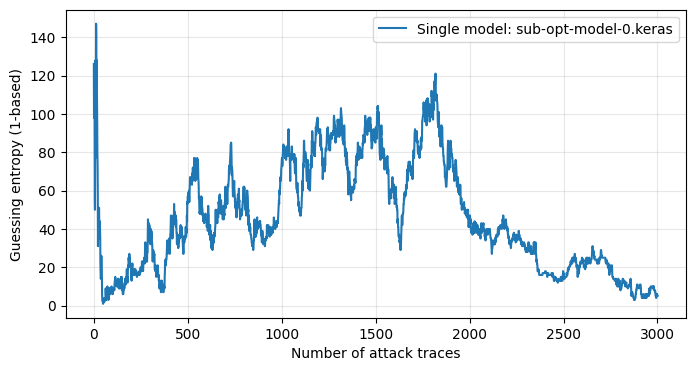

In [16]:
# Calculating GE

from sklearn.utils import shuffle
import matplotlib.pyplot as plt

single_model = model_files[0]  # Set this to the filename of the best pretrained model.
runs = 50
num_attack_traces = 3000
assert runs > 0 and 0 < num_attack_traces <= n_attack
HW = [bin(value).count('1') for value in range(256)]

def calculate_ge(log_probabilities):
    # Map predicted class probabilities to the 256 key hypotheses.
    iv = [128, 64, 12, 6, 0, 0, 0, 0]
    nonce0 = attack_data[:, 2]
    nonce1 = attack_data[:, 3]
    hypothesis_probabilities = np.zeros((n_attack, 256))

    for index in range(n_attack):
        for hypothesis in range(256):
            key1 = hypothesis

            if leakage_model == "SB-8":
              hypothesis_probabilities[index, hypothesis] = log_probabilities[
                  index, nonce0[index] ^ nonce1[index] ^ (iv[target_byte] & key1) ^ (nonce1[index] & key1) ^ key1]
            elif leakage_model == "HW":
              hypothesis_probabilities[index, hypothesis] = probabilities[
                  index, HW[nonce0[index] ^ nonce1[index] ^ (iv[target_byte] & key1) ^ (nonce1[index] & key1) ^ key1]]

    # Accumulate scores and average the correct-key rank over repeated attacks.
    key_ranking_sum = np.zeros(num_attack_traces)
    for run in range(runs):
        shuffled_probabilities = shuffle(hypothesis_probabilities, random_state=0)
        key_probabilities = np.zeros(256)

        for index in range(num_attack_traces):
            key_probabilities += shuffled_probabilities[index]
            key_probabilities_sorted = np.argsort(key_probabilities)[::-1]

            correct_key_rank = list(key_probabilities_sorted).index(good_key) + 1
            key_ranking_sum[index] += correct_key_rank

    return key_ranking_sum / runs

log_probabilities = np.log(best_model_probabilities.astype(np.float64) + 1e-40)
ge_single = calculate_ge(log_probabilities)
print(f'Final GE for {single_model}: {ge_single[-1]:.2f}')

trace_axis = np.arange(1, num_attack_traces + 1)
plt.figure(figsize=(8, 4))
plt.plot(trace_axis, ge_single, label=f'Single model: {single_model}')
plt.xlabel('Number of attack traces')
plt.ylabel('Guessing entropy (1-based)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Load the suboptimal model and the GE of the ensemble of models
Ensemble of model is a cheap solution to improve the efficiency of an attack without the need to search for better models or mo

In [13]:
model_folder = Path('/content/Ensemble-Trained-Models/')
model_files = ['sub-opt-model-0.keras', 'sub-opt-model-1.keras', 'sub-opt-model-2.keras', 'sub-opt-model-3.keras', 'sub-opt-model-4.keras']
batch_size = 128

assert model_files and len(set(model_files)) == len(model_files), 'Use unique model filenames.'
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass  # The GPU may already be initialized if this cell is rerun.

probabilities_all = {}
for filename in model_files:
    print('Loading', filename)
    model = load_model(model_folder/filename, compile=False)

    # MLPs use (traces, samples); the original CNNs also need a channel dimension.
    model_input = X_attack[..., np.newaxis] if len(model.input_shape) == 3 else X_attack
    probabilities = model.predict(model_input, batch_size=batch_size, verbose=1)
    expected_classes = 9 if leakage_model == 'HW' else 256
    assert probabilities.shape == (n_attack, expected_classes), 'Unexpected model output shape.'
    probabilities_all[filename] = probabilities

    del model
    K.clear_session()
    gc.collect()

print('Predictions available for', len(probabilities_all), 'model(s).')

Loading sub-opt-model-0.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Loading sub-opt-model-1.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Loading sub-opt-model-2.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Loading sub-opt-model-3.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Loading sub-opt-model-4.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Predictions available for 5 model(s).


Final GE for the single model: 5.00
Final GE for the ensemble of 5 model(s): 1.00


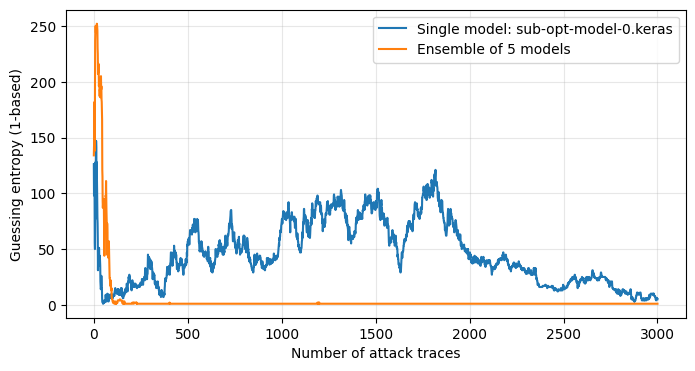

In [14]:
# Combine model predictions by summing log probabilities, as in the original project.
ensemble_log_probabilities = np.zeros_like(probabilities_all[model_files[0]], dtype=np.float64)
for filename in model_files:
    ensemble_log_probabilities += np.log(probabilities_all[filename].astype(np.float64) + 1e-40)

ge_ensemble = calculate_ge(ensemble_log_probabilities)
print(f'Final GE for the single model: {ge_single[-1]:.2f}')
print(f'Final GE for the ensemble of {len(model_files)} model(s): {ge_ensemble[-1]:.2f}')

plt.figure(figsize=(8, 4))
plt.plot(trace_axis, ge_single, label=f'Single model: {single_model}')
plt.plot(trace_axis, ge_ensemble, label=f'Ensemble of {len(model_files)} models')
plt.xlabel('Number of attack traces')
plt.ylabel('Guessing entropy (1-based)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
